<a href="https://colab.research.google.com/github/christabel-sky01/Adidas-sale-dashboard/blob/main/Online_Retail.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving Retail online dataset 1.xlsx to Retail online dataset 1.xlsx


In [ ]:
import os

print(os.listdir('/content'))


['.config', 'Retail online dataset 1.xlsx', 'sample_data']


In [ ]:
import pandas as pd

ecommerce_df = pd.read_excel('/content/Retail online dataset 1.xlsx')

# Display the first 5 rows
ecommerce_df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [10]:
ecommerce_df.head()
ecommerce_df.info()
ecommerce_df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


(541909, 8)

In [11]:
import pandas as pd

df = pd.read_excel('/content/Retail online dataset 1.xlsx')

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [12]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [13]:
print("Shape of dataset:", df.shape)
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Shape of dataset: (541909, 8)
Number of rows: 541909
Number of columns: 8


In [14]:
numerical_features = df.select_dtypes(include=['int64', 'float64']).columns
print("Numerical Features:")
print(numerical_features)

Numerical Features:
Index(['Quantity', 'UnitPrice', 'CustomerID'], dtype='object')


In [16]:
categorical_features = df.select_dtypes(include=['object']).columns
print("Categorical Features:")
print(categorical_features)

Categorical Features:
Index(['InvoiceNo', 'StockCode', 'Description', 'Country'], dtype='object')


In [17]:
print("Unique Invoice Numbers:", df['InvoiceNo'].nunique())
print("Unique Stock Codes:", df['StockCode'].nunique())
print("Unique Customer IDs:", df['CustomerID'].nunique())

Unique Invoice Numbers: 25900
Unique Stock Codes: 4070
Unique Customer IDs: 4372


In [18]:
print("""
This dataset contains online retail transactions, including information about products purchased,
quantities ordered, unit prices, customer identifiers, invoice details, and countries where the purchases occurred.
""")


This dataset contains online retail transactions, including information about products purchased,
quantities ordered, unit prices, customer identifiers, invoice details, and countries where the purchases occurred.



In [19]:
df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


In [21]:
# Remove rows with missing CustomerID
df = df.dropna(subset=['CustomerID'])

# Replace missing descriptions
df['Description'] = df['Description'].fillna('Unknown')

In [22]:
duplicates = df.duplicated().sum()
print("Duplicates:", duplicates)

Duplicates: 5225


In [23]:
df = df.drop_duplicates()

print("Duplicates removed:", duplicates)

Duplicates removed: 5225


In [24]:
df.columns = df.columns.str.lower().str.strip()

df.columns

Index(['invoiceno', 'stockcode', 'description', 'quantity', 'invoicedate',
       'unitprice', 'customerid', 'country'],
      dtype='object')

In [25]:
df['invoicedate'] = pd.to_datetime(df['invoicedate'])

df['invoicedate'].head()

,invoicedate
0,2010-12-01 08:26:00
1,2010-12-01 08:26:00
2,2010-12-01 08:26:00
3,2010-12-01 08:26:00
4,2010-12-01 08:26:00


In [26]:
df['description'] = df['description'].str.upper()
df['country'] = df['country'].str.title()

In [27]:
df[df['quantity'] <= 0].head()

,invoiceno,stockcode,description,quantity,invoicedate,unitprice,customerid,country
141,C536379,D,DISCOUNT,-1,2010-12-01 09:41:00,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom


In [28]:
df = df[df['quantity'] > 0]

In [29]:
df = df[df['unitprice'] > 0]

In [30]:
df['revenue'] = df['quantity'] * df['unitprice']

In [31]:
cleaning_summary = pd.DataFrame({
    'Issue Found': [
        'Missing Values',
        'Duplicates',
        'Invalid Quantity',
        'Invalid Unit Price',
        'Standardization'
    ],
    'Action Taken': [
        'Dropped missing CustomerID and filled Description',
        'Removed duplicate rows',
        'Removed Quantity ≤ 0',
        'Removed UnitPrice ≤ 0',
        'Standardized dates, text, and column names'
    ]
})

cleaning_summary

,Issue Found,Action Taken
0,Missing Values,Dropped missing CustomerID and filled Description
1,Duplicates,Removed duplicate rows
2,Invalid Quantity,Removed Quantity ≤ 0
3,Invalid Unit Price,Removed UnitPrice ≤ 0
4,Standardization,"Standardized dates, text, and column names"


In [32]:
df.to_excel('cleaned_ecommerce_dataset.xlsx', index=False)

In [33]:
df.describe()

,quantity,invoicedate,unitprice,customerid,revenue
count,392692.000000,392692,392692.000000,392692.000000,392692.000000
mean,13.119702,2011-07-10 19:13:07.771892480,3.125914,15287.843865,22.631500
min,1.000000,2010-12-01 08:26:00,0.001000,12346.000000,0.001000
25%,2.000000,2011-04-07 11:12:00,1.250000,13955.000000,4.950000
50%,6.000000,2011-07-31 12:02:00,1.950000,15150.000000,12.450000
75%,12.000000,2011-10-20 12:53:00,3.750000,16791.000000,19.800000
max,80995.000000,2011-12-09 12:50:00,8142.750000,18287.000000,168469.600000
std,180.492832,NaN,22.241836,1713.539549,311.099224


In [34]:
df.mean(numeric_only=True)

,0
quantity,13.119702
unitprice,3.125914
customerid,15287.843865
revenue,22.631500


In [35]:
df.median(numeric_only=True)

,0
quantity,6.00
unitprice,1.95
customerid,15150.00
revenue,12.45


In [36]:
df.min(numeric_only=True)

,0
quantity,1.000
unitprice,0.001
customerid,12346.000
revenue,0.001


In [37]:
df.max(numeric_only=True)

,0
quantity,80995.00
unitprice,8142.75
customerid,18287.00
revenue,168469.60


In [38]:
df.std(numeric_only=True)

,0
quantity,180.492832
unitprice,22.241836
customerid,1713.539549
revenue,311.099224


Exploratory Analyses

In [39]:
top_products = df.groupby('description')['quantity'].sum().sort_values(ascending=False).head(10)

top_products

,quantity
description,
"PAPER CRAFT , LITTLE BIRDIE",80995
MEDIUM CERAMIC TOP STORAGE JAR,77916
WORLD WAR 2 GLIDERS ASSTD DESIGNS,54319
JUMBO BAG RED RETROSPOT,46078
WHITE HANGING HEART T-LIGHT HOLDER,36706
ASSORTED COLOUR BIRD ORNAMENT,35263
PACK OF 72 RETROSPOT CAKE CASES,33670
POPCORN HOLDER,30919
RABBIT NIGHT LIGHT,27153


In [40]:
country_revenue = df.groupby('country')['revenue'].sum().sort_values(ascending=False).head(10)

country_revenue

,revenue
country,
United Kingdom,7285024.644
Netherlands,285446.340
Eire,265262.460
Germany,228678.400
France,208934.310
Australia,138453.810
Spain,61558.560
Switzerland,56443.950
Belgium,41196.340


In [41]:
df['month'] = df['invoicedate'].dt.to_period('M')

monthly_sales = df.groupby('month')['revenue'].sum()

monthly_sales

,revenue
month,
2010-12,570422.730
2011-01,568101.310
2011-02,446084.920
2011-03,594081.760
2011-04,468374.331
2011-05,677355.150
2011-06,660046.050
2011-07,598962.901
2011-08,644051.040


In [42]:
most_purchased = df['description'].value_counts().head(10)

most_purchased

,count
description,
WHITE HANGING HEART T-LIGHT HOLDER,2016
REGENCY CAKESTAND 3 TIER,1713
JUMBO BAG RED RETROSPOT,1615
ASSORTED COLOUR BIRD ORNAMENT,1395
PARTY BUNTING,1389
LUNCH BAG RED RETROSPOT,1303
SET OF 3 CAKE TINS PANTRY DESIGN,1152
POSTAGE,1099
LUNCH BAG BLACK SKULL.,1078


In [43]:
customer_behavior = df.groupby('customerid')['revenue'].sum().sort_values(ascending=False).head(10)

customer_behavior

,revenue
customerid,
14646.0,280206.02
18102.0,259657.30
17450.0,194390.79
16446.0,168472.50
14911.0,143711.17
12415.0,124914.53
14156.0,117210.08
17511.0,91062.38
16029.0,80850.84


DATA VISUALIZATION


In [44]:
import matplotlib.pyplot as plt

In [46]:
print(df.columns)

Index(['invoiceno', 'stockcode', 'description', 'quantity', 'invoicedate',
       'unitprice', 'customerid', 'country', 'revenue', 'month'],
      dtype='object')


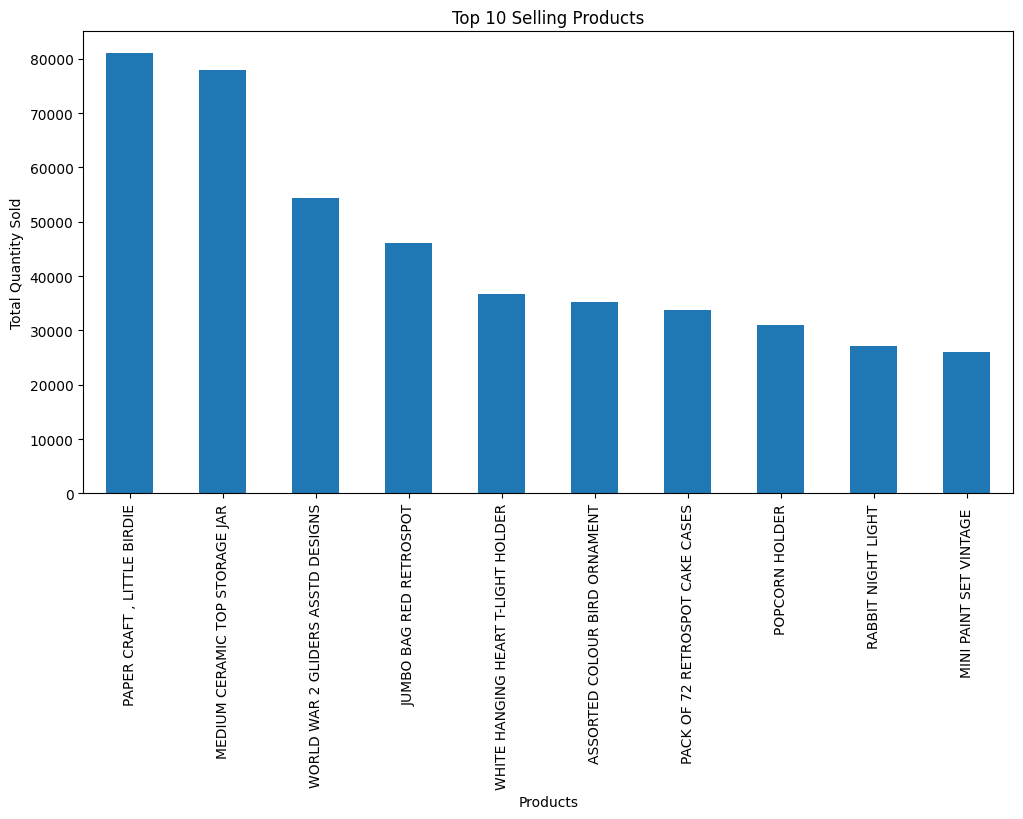

In [47]:
import matplotlib.pyplot as plt

top_products = df.groupby('description')['quantity'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))
top_products.plot(kind='bar')
plt.title('Top 10 Selling Products')
plt.xlabel('Products')
plt.ylabel('Total Quantity Sold')
plt.xticks(rotation=90)
plt.show()

Finding: This chart identifies the products with the highest sales volumes

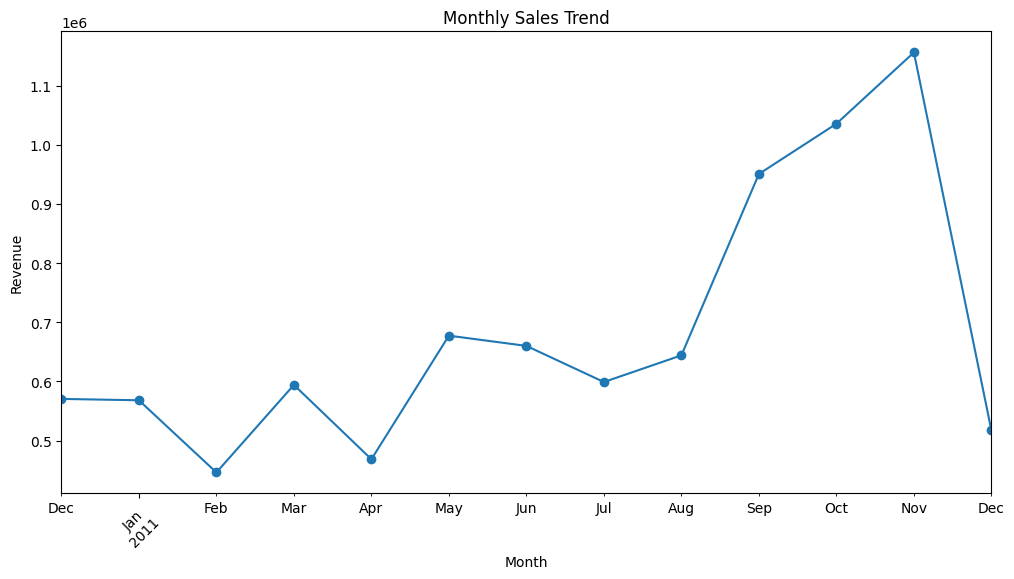

In [48]:
monthly_sales = df.groupby('month')['revenue'].sum()

plt.figure(figsize=(12,6))
monthly_sales.plot(kind='line', marker='o')
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.show()

Finding: This visualization shows how revenue changes over time.

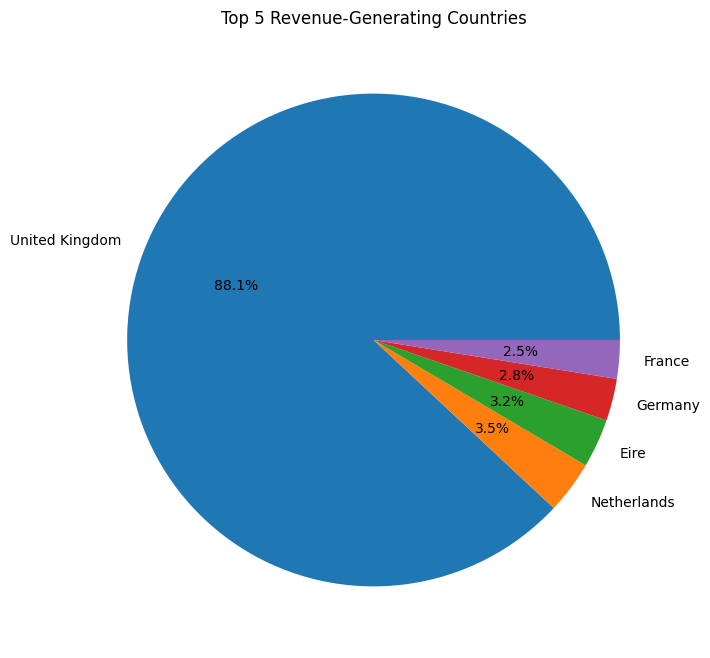

In [49]:
top_countries = df.groupby('country')['revenue'].sum().sort_values(ascending=False).head(5)

plt.figure(figsize=(8,8))
top_countries.plot(kind='pie', autopct='%1.1f%%')
plt.title('Top 5 Revenue-Generating Countries')
plt.ylabel('')
plt.show()

Finding: This chart highlights the countries contributing the most revenue.

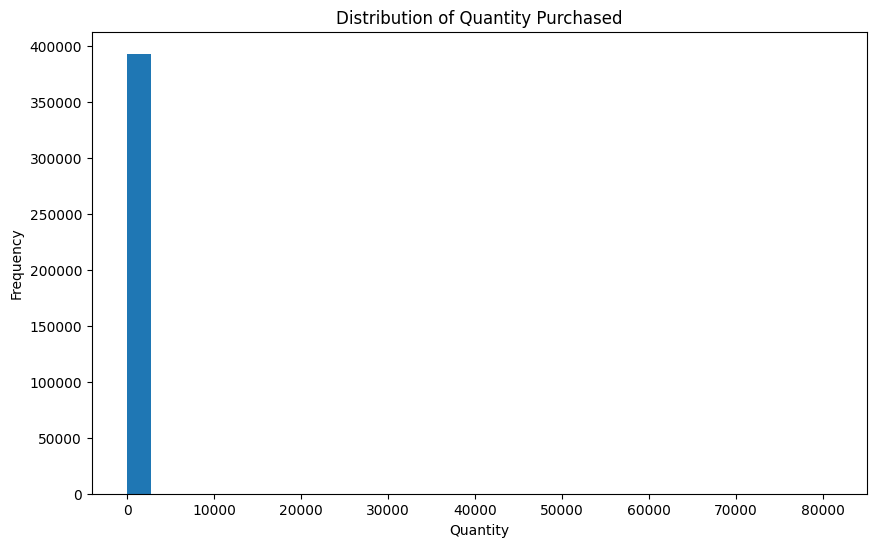

In [50]:
plt.figure(figsize=(10,6))
plt.hist(df['quantity'], bins=30)
plt.title('Distribution of Quantity Purchased')
plt.xlabel('Quantity')
plt.ylabel('Frequency')
plt.show()

Finding: Most purchases involve smaller quantities.

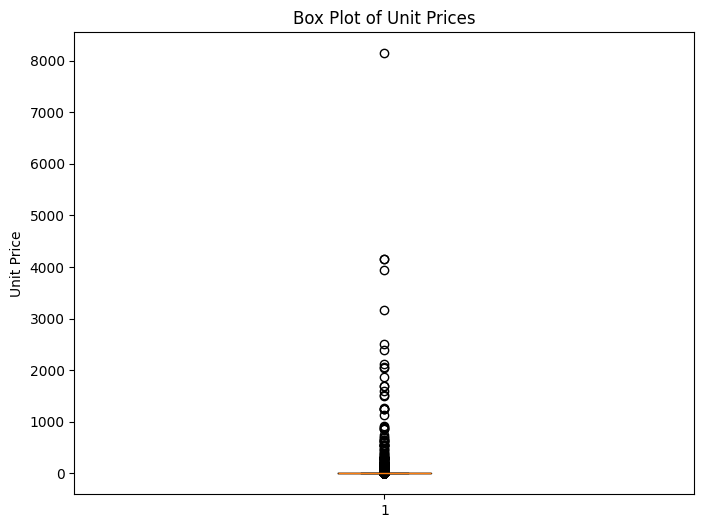

In [51]:
plt.figure(figsize=(8,6))
plt.boxplot(df['unitprice'])
plt.title('Box Plot of Unit Prices')
plt.ylabel('Unit Price')
plt.show()

Finding: The box plot helps identify outliers and price variations.

Insight 1: Top-Selling Products Drive Most Revenue

From the Bar Chart of Top 10 Selling Products, we observed that a small number of products account for a large portion of total sales.

This shows a high concentration of demand, meaning the business relies heavily on a few best-selling items.

# Supported by: Top 10 Selling Products (Bar Chart)

🔹 Insight 2: United Kingdom Dominates Sales Revenue

The Pie Chart of Top 5 Revenue-Generating Countries shows that the United Kingdom contributes the highest percentage of total revenue.

This indicates that the business is heavily UK-centered, with limited international diversification.

# Supported by: Revenue by Country (Pie Chart)

🔹 Insight 3: Sales Fluctuate Over Time (Seasonality)

The Monthly Sales Trend Line Chart shows clear ups and downs in revenue across months.

This suggests that customer purchasing behavior is influenced by seasonal demand patterns, holidays, or promotions.

# Supported by: Monthly Sales Trend (Line Chart)

🔹 Insight 4: Most Transactions Are Low-Quantity Purchases

The Histogram of Quantity Distribution shows that most customers purchase items in small quantities.

This indicates that the business primarily serves retail or small-order buyers, rather than bulk wholesale customers.

# Supported by: Quantity Distribution (Histogram)

🔹 Insight 5: Presence of High-Priced Outliers in Products

The Box Plot of Unit Prices reveals several outliers with very high unit prices compared to the majority of products.

This suggests the presence of premium or specialty items in the product catalog.

# Supported by: Unit Price Distribution (Box Plot)